# Proyecto 2 y 3 – Ciencia de Datos
## Dataset: Avocado Prices (Precios de Aguacate)




# Análisis Descriptivo del Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
df = pd.read_csv('avocado.csv')
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [3]:
print(f'Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas\n')
df.info()

Dimensiones del dataset: 18249 filas × 14 columnas

<class 'pandas.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  str    
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  str    
 12  year          18249 non-null  int64  
 13  region        18249 non-null  str    
dtypes: float64(9), int64(2), str(3)
memory usage: 1.9 MB


In [4]:
df.describe()

,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


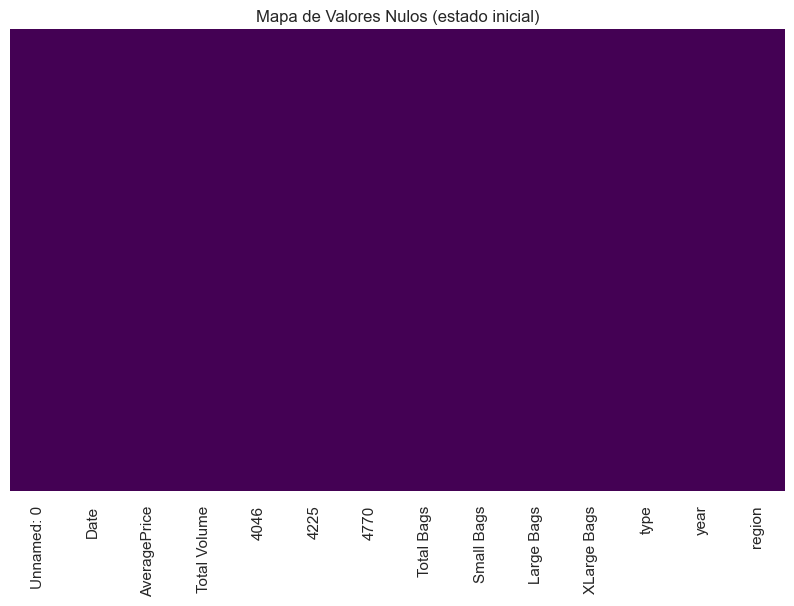

Valores nulos por columna:
Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64


In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cmap='viridis', cbar=False, yticklabels=False)
plt.title('Mapa de Valores Nulos (estado inicial)')
plt.show()
nulos = df.isnull().sum()
print('Valores nulos por columna:')
print(nulos[nulos >= 0])

In [6]:
print('Tipos de aguacate:', df['type'].unique())
print('Número de regiones:', df['region'].nunique())
print('Rango de años:', df['year'].unique())

Tipos de aguacate: <StringArray>
['conventional', 'organic']
Length: 2, dtype: str
Número de regiones: 54
Rango de años: [2015 2016 2017 2018]


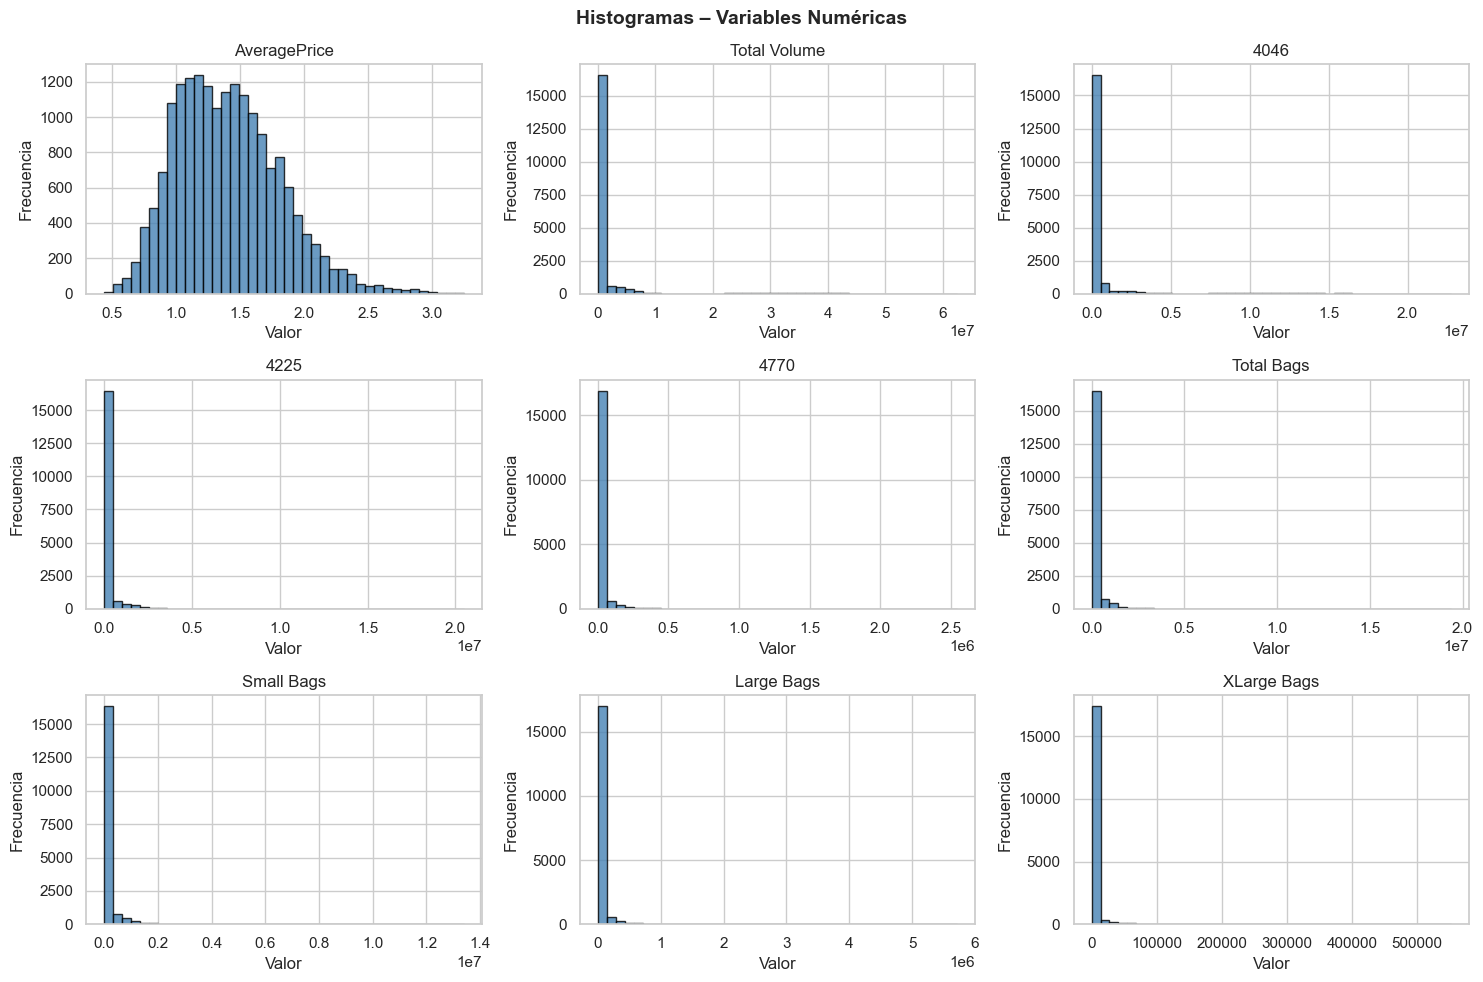

In [7]:
num_cols = ['AveragePrice', 'Total Volume', '4046', '4225', '4770',
            'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, edgecolor='black', color='steelblue', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Histogramas – Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Insights:
- AveragePrice sigue una distribución aproximadamente normal con sesgo leve a la derecha.
- Total Volume y Total Bags tienen distribuciones muy sesgadas (muchos registros de bajo
  volumen y algunos con volúmenes muy altos -> posibles outliers).
- 4770 (PLU code de Hass extra grande) tiene muy poca frecuencia, lo que indica que
  ese tipo de aguacate se vende poco.

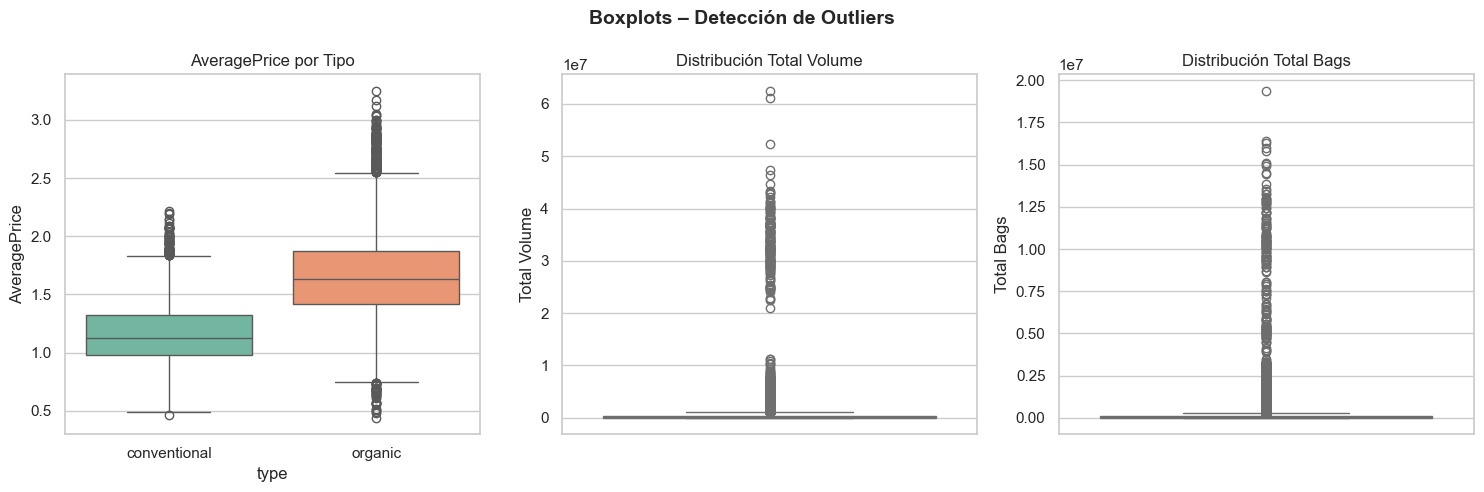

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, y='AveragePrice', x='type', ax=axes[0], palette='Set2')
axes[0].set_title('AveragePrice por Tipo')

sns.boxplot(data=df, y='Total Volume', ax=axes[1], color='skyblue')
axes[1].set_title('Distribución Total Volume')

sns.boxplot(data=df, y='Total Bags', ax=axes[2], color='salmon')
axes[2].set_title('Distribución Total Bags')

plt.suptitle('Boxplots – Detección de Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Insights:
- Los aguacates 'organic' tienen precios significativamente más altos que los
  convencionales, con mayor variabilidad.
- Total Volume y Total Bags presentan outliers extremos (puntos por encima del bigote
  superior) que deberán ser tratados en la fase de limpieza.
- El tipo de aguacate influye mucho en el precio

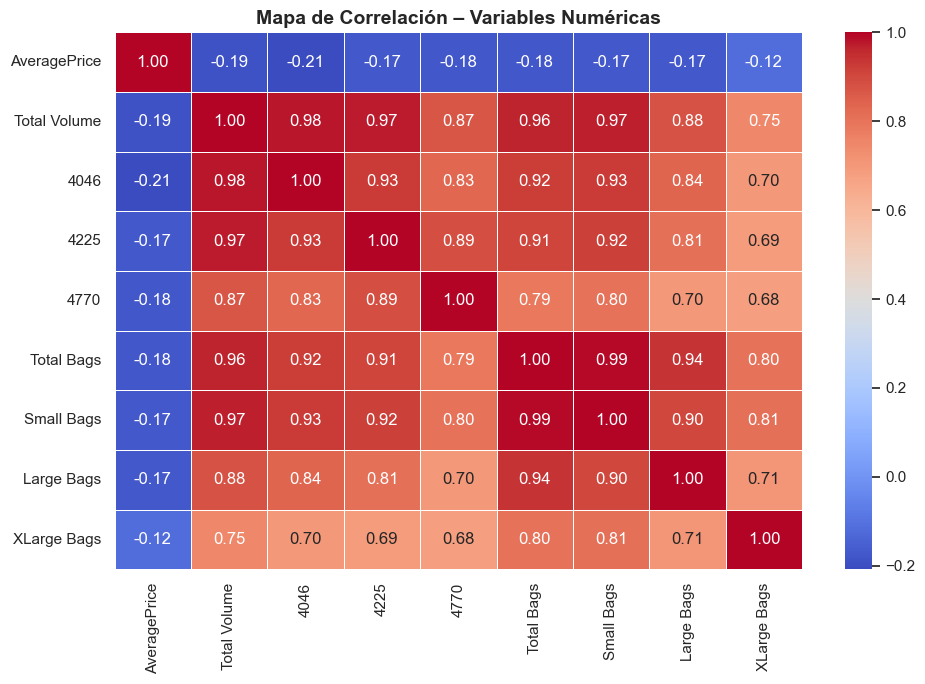

In [9]:
corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de Correlación – Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Insights Corregidos:

- `Total Volume`, `Total Bags` y `Small Bags` están **altamente correlacionadas** entre sí (r > 0.96), lo que indica **multicolinealidad severa**. `Large Bags` tiene una correlación algo más baja con `Total Volume` (r = 0.88), pero sigue siendo fuerte.

- `AveragePrice` tiene una **correlación negativa débil** con `Total Volume` (r = -0.19), lo que sugiere que **el volumen de ventas explica muy poca variabilidad en el precio**. Otros factores como `type`, `region` probablemente son más determinantes.

- Los PLU codes (`4046`, `4225`, `4770`) tienen **alta correlación con `Total Volume`** (r > 0.87), lo cual es esperable ya que son componentes del volumen total.

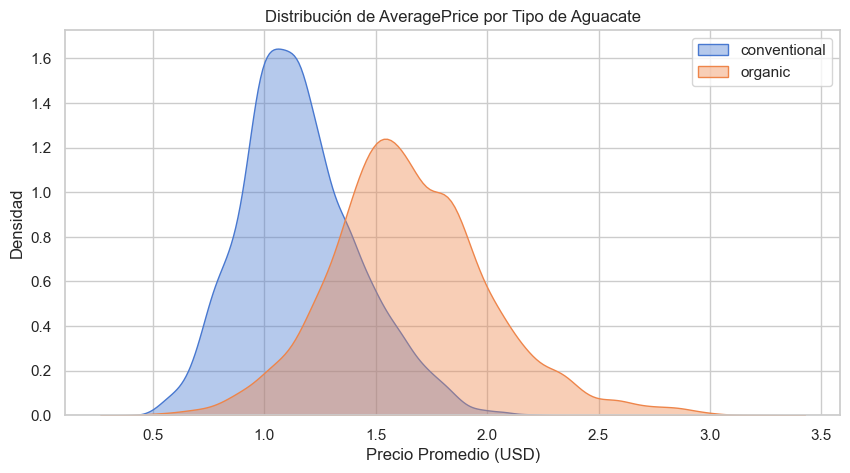

In [10]:
####### Distribución de AveragePrice por tipo de aguacate #############
plt.figure(figsize=(10, 5))
for t in df['type'].unique():
    subset = df[df['type'] == t]['AveragePrice']
    sns.kdeplot(subset, label=t, fill=True, alpha=0.4)
plt.title('Distribución de AveragePrice por Tipo de Aguacate')
plt.xlabel('Precio Promedio (USD)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

### Insights - Distribución de AveragePrice por tipo de aguacate:

- **El aguacate orgánico alcanza precios significativamente más altos** que el convencional, con valores máximos de ~3.00 USD frente a ~2.00 USD del convencional.

- **El pico de densidad del convencional es más alto** (~1.60 USD) porque tiene muchos más registros en ese rango, mientras que el orgánico tiene su pico en ~1.20 USD pero con **menor concentración y cola más larga hacia precios premium**.

El orgánico es **más caro en sus valores extremos**, pero el convencional es más frecuente en el rango de precios medios-altos (~1.60 USD).

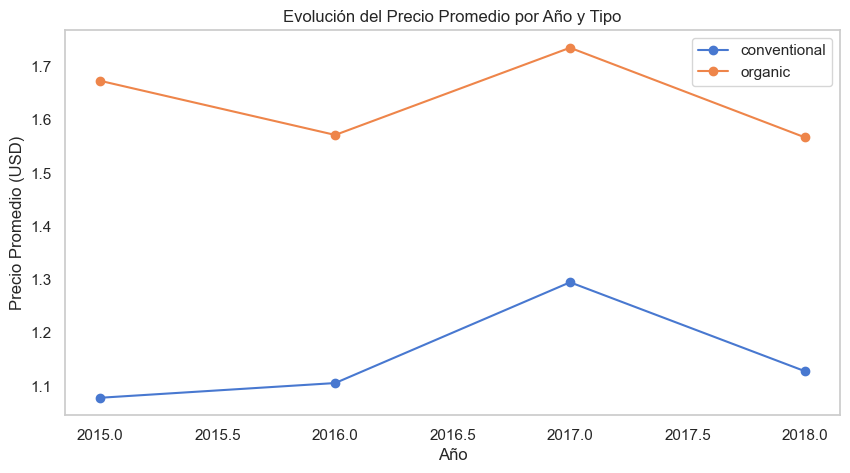

In [11]:
########## Evolución del precio promedio anual ###############
precio_anual = df.groupby(['year', 'type'])['AveragePrice'].mean().reset_index()

plt.figure(figsize=(10, 5))
for t in precio_anual['type'].unique():
    sub = precio_anual[precio_anual['type'] == t]
    plt.plot(sub['year'], sub['AveragePrice'], marker='o', label=t)
plt.title('Evolución del Precio Promedio por Año y Tipo')
plt.xlabel('Año')
plt.ylabel('Precio Promedio (USD)')
plt.legend()
plt.grid()
plt.show()

### Insights - Evolución del Precio Promedio por Año y Tipo:

- **El aguacate orgánico es consistentemente más caro** que el convencional durante todo el período 2015-2018.

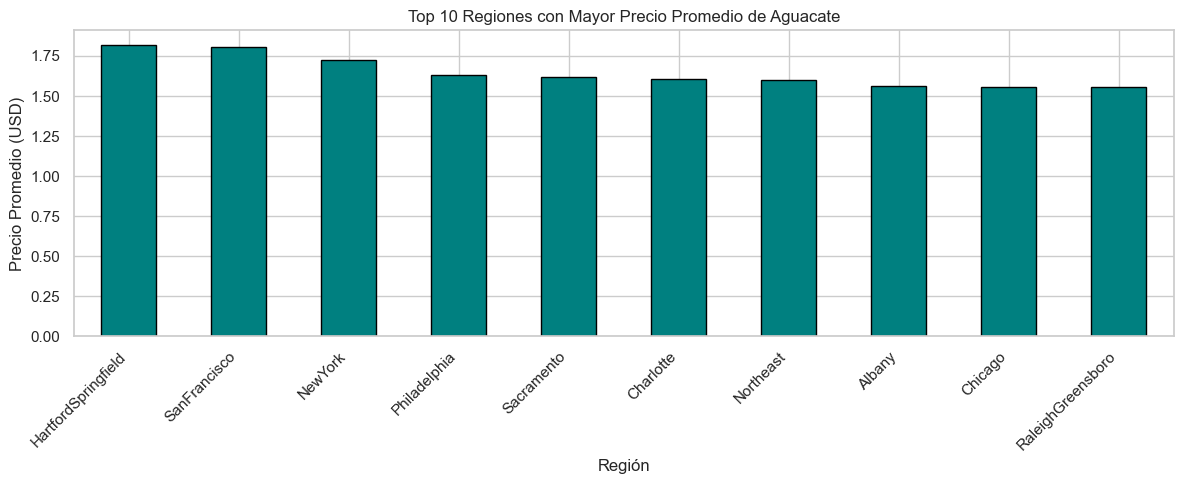

In [12]:
######### Top 10 regiones con mayor precio promedio ################
top_regiones = df.groupby('region')['AveragePrice'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_regiones.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 10 Regiones con Mayor Precio Promedio de Aguacate')
plt.xlabel('Región')
plt.ylabel('Precio Promedio (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Insights - Top 10 Regiones con Mayor Precio Promedio:

- **HartfordSpringfield** es la región con el precio promedio más alto de todas (~1.80 USD aproximadamente).

- **San Francisco** y **New York** también se encuentran entre las regiones más caras.

- **La diferencia entre la primera (HartfordSpringfield) y la décima (Raleigh/Greensboro) es relativamente pequeña** (~0.20-0.30 USD), lo que indica que los precios del aguacate no varían drásticamente entre regiones top.

# Fase 2  Limpieza y Normalización de Datos

In [13]:
df_clean = df.copy()

# Eliminar columna innecesaria (índice duplicado que viene del CSV)
if 'Unnamed: 0' in df_clean.columns:
    df_clean.drop(columns=['Unnamed: 0'], inplace=True)

print('Columnas actuales:', df_clean.columns.tolist())
print('Shape:', df_clean.shape)

Columnas actuales: ['Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year', 'region']
Shape: (18249, 13)


### Eliminación de columnas innecesarias
Se eliminó la columna `Unnamed: 0`, ya que corresponde a un índice generado automáticamente y no aporta información relevante para el análisis.

In [14]:
########## Detección y eliminación de duplicados #####################
n_dup = df_clean.duplicated().sum()
# No tengo registros duplicados en el dataset
print(f'Registros duplicados encontrados: {n_dup}')
df_clean.drop_duplicates(inplace=True)
print(f'Shape después de eliminar duplicados: {df_clean.shape}')

Registros duplicados encontrados: 0
Shape después de eliminar duplicados: (18249, 13)


In [15]:
######## Conversión de columna Date a datetime ##################
## Normalización de la data mas de la fecha ##### 
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['month'] = df_clean['Date'].dt.month
df_clean['week'] = df_clean['Date'].dt.isocalendar().week.astype(int)
print('Columnas de fecha extraídas: month, week')
df_clean[['Date', 'month', 'week', 'year']].head()

Columnas de fecha extraídas: month, week


,Date,month,week,year
0,2015-12-27,12,52,2015
1,2015-12-20,12,51,2015
2,2015-12-13,12,50,2015
3,2015-12-06,12,49,2015
4,2015-11-29,11,48,2015


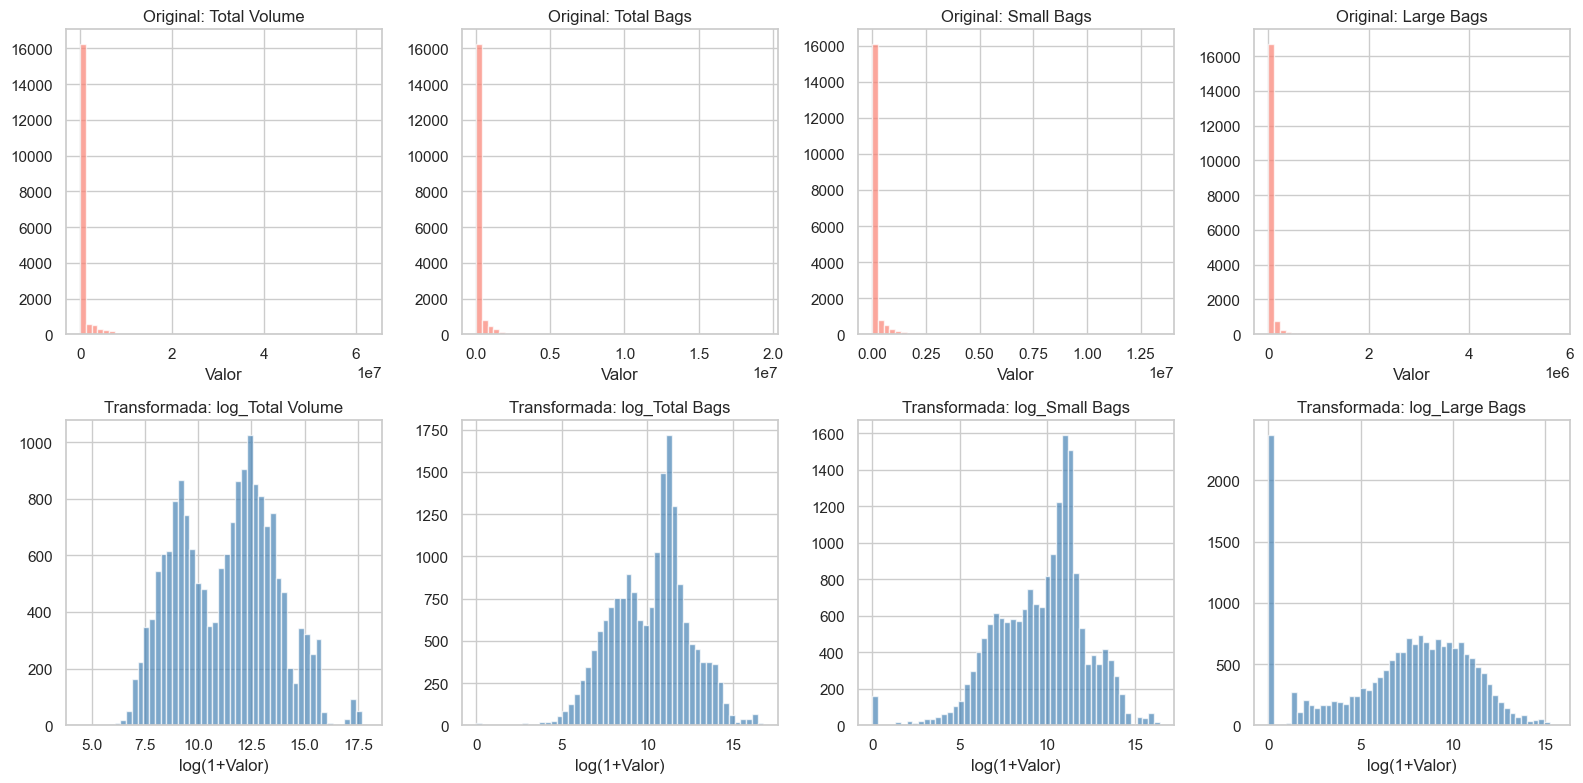

Variables originales reemplazadas por su versión log(1+x):
['Total Volume', 'Total Bags', 'Small Bags', 'Large Bags']

📋 Columnas finales en df_clean:
['Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year', 'region', 'month', 'week']


In [16]:
########## Transformación logarítmica y reemplazo de variables ##########

import numpy as np

cols_to_transform = ['Total Volume', 'Total Bags', 'Small Bags', 'Large Bags']

# Crear versiones log para visualizar
for col in cols_to_transform:
    df_clean[f'log_{col}'] = np.log1p(df_clean[col])

# Visualizar comparación
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, col in enumerate(cols_to_transform):
    # Distribución original
    axes[0, i].hist(df_clean[col], bins=50, color='salmon', alpha=0.7)
    axes[0, i].set_title(f'Original: {col}')
    axes[0, i].set_xlabel('Valor')
    
    # Distribución transformada
    axes[1, i].hist(df_clean[f'log_{col}'], bins=50, color='steelblue', alpha=0.7)
    axes[1, i].set_title(f'Transformada: log_{col}')
    axes[1, i].set_xlabel('log(1+Valor)')

plt.tight_layout()
plt.show()

# REEMPLAZAR: Sobrescribir las columnas originales con las versiones log
for col in cols_to_transform:
    df_clean[col] = df_clean[f'log_{col}']

# Eliminar las columnas log temporales (opcional, para no tener duplicadas)
for col in cols_to_transform:
    df_clean.drop(columns=[f'log_{col}'], inplace=True)

print("Variables originales reemplazadas por su versión log(1+x):")
print(cols_to_transform)
print("\n📋 Columnas finales en df_clean:")
print(df_clean.columns.tolist())

### Tratamiento de variables sesgadas (sin eliminación de datos)

En lugar de eliminar outliers, se aplicó una **transformación logarítmica (log1p)** a las variables `Total Volume`, `Total Bags`, `Small Bags` y `Large Bags`. Esta técnica:

- Preserva la totalidad de los **18,249 registros** originales.
- Reduce el impacto de la asimetría y los valores extremos.
- Maneja correctamente los valores cero (log1p(0) = 0).
- Mejora el cumplimiento de supuestos para modelos lineales.

Las variables transformadas se almacenan como `log_Total_Volume`, `log_Total_Bags`, `log_Small_Bags` y `log_Large_Bags`, manteniendo las originales para referencia o análisis alternativos.
### Resultados de la Transformación Logarítmica (log1p):

- **Antes (original)**: Distribuciones extremadamente sesgadas a la derecha, con gran concentración de valores bajos/ceros y colas muy largas hacia valores altos.

- **Después (transformada)**: 
  - Las distribuciones de `log_Total Volume`, `log_Small Bags`, `log_Large Bags` y `log_Total Bags` ahora presentan una forma **aproximadamente normal o uniforme**.
  - El rango de valores se ha comprimido (ej. de valores originales hasta millones a valores transformados entre 0 y ~8-9).
  - Los ceros originales se mantienen como 0 (log1p(0) = 0).

- **Beneficio clave**: Se preservaron **todos los 18,249 registros** originales, a diferencia del enfoque de eliminación que hubiera descartado ~3,820 registros (~21%).

- **Conclusión**: El dataset ahora es mucho más adecuado para modelos lineales (regresión, correlaciones) y algoritmos sensibles a la escala de los datos, sin pérdida de información.

In [17]:
# #### Conversión de variables categóricas a dummies (One-Hot Encoding) ######
df_model = df_clean.copy()

# Codificamos 'type'
df_model = pd.get_dummies(df_model, columns=['type'], drop_first=True)
# La nueva columna se llamará 'type_organic' (1=organic, 0=conventional)

# Codificamos 'region' usando LabelEncoder (para evitar la explosión de columnas)
le = LabelEncoder()
df_model['region_encoded'] = le.fit_transform(df_model['region'])

print('Columnas después de encoding:')
print(df_model.columns.tolist())

Columnas después de encoding:
['Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'year', 'region', 'month', 'week', 'type_organic', 'region_encoded']


In [18]:
###### Estandarización y normalización ##### 
# Seleccionamos las features para el modelo
feature_cols = ['Total Volume', '4046', '4225', '4770',
                'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags',
                'year', 'month', 'week', 'type_organic', 'region_encoded']

target_col = 'AveragePrice'

X = df_model[feature_cols].copy()
y = df_model[target_col].copy()

# Estandarización con StandardScaler (media=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print('Estadísticas después de estandarizar:')
X_scaled.describe().round(2)

Estadísticas después de estandarizar:


,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year,month,week,type_organic,region_encoded
count,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.0,18249.00
mean,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.0,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.00
min,-2.99,-0.23,-0.25,-0.21,-4.51,-3.77,-1.85,-0.18,-1.22,-1.46,-1.57,-1.0,-1.70
25%,-0.88,-0.23,-0.24,-0.21,-0.73,-0.68,-0.59,-0.18,-1.22,-0.90,-0.92,-1.0,-0.87
50%,0.12,-0.22,-0.22,-0.21,0.18,0.19,0.20,-0.18,-0.16,-0.05,-0.02,-1.0,-0.03
75%,0.72,-0.14,-0.12,-0.15,0.63,0.63,0.75,-0.17,0.91,0.80,0.89,1.0,0.87
max,2.89,17.75,16.76,23.48,2.91,2.61,2.20,31.01,1.97,1.65,1.79,1.0,1.70


In [19]:
######## División Train / Test ###################
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'Entrenamiento: {X_train.shape[0]} registros')
print(f'Prueba:        {X_test.shape[0]} registros')

Entrenamiento: 14599 registros
Prueba:        3650 registros


---
# Fase 3: Implementación de Modelos Predictivos

Se entrena y compara el desempeño de **tres modelos de regresión** para predecir `AveragePrice`:
1. **Regresión Lineal** – modelo base de referencia
2. **Random Forest Regressor** – modelo de ensamble basado en árboles
3. **Red Neuronal (MLP)** – modelo de aprendizaje profundo superficial

In [20]:
######## Función de evaluación de modelos ############
def evaluar_modelo(nombre, y_real, y_pred):
    mse  = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    print(f'─── {nombre} ───')
    print(f'  MSE  : {mse:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  R²   : {r2:.4f}\n')
    return {'Modelo': nombre, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

In [21]:
########## Modelo 1: Regresión Lineal #############
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

res_lr = evaluar_modelo('Regresión Lineal', y_test, y_pred_lr)

─── Regresión Lineal ───
  MSE  : 0.0790
  RMSE : 0.2810
  MAE  : 0.2182
  R²   : 0.5085



In [22]:
######## Modelo 2: Random Forest Regressor ##########
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

res_rf = evaluar_modelo('Random Forest Regressor', y_test, y_pred_rf)

─── Random Forest Regressor ───
  MSE  : 0.0165
  RMSE : 0.1285
  MAE  : 0.0897
  R²   : 0.8973



In [23]:
############# Modelo 3: Red Neuronal (MLP) #################
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=300,
    random_state=42
)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

res_mlp = evaluar_modelo('Red Neuronal (MLP)', y_test, y_pred_mlp)

─── Red Neuronal (MLP) ───
  MSE  : 0.0224
  RMSE : 0.1497
  MAE  : 0.1092
  R²   : 0.8605



In [24]:
####### Tabla comparativa de métricas ###############
resultados = pd.DataFrame([res_lr, res_rf, res_mlp])
resultados.set_index('Modelo', inplace=True)
resultados.round(4)

,MSE,RMSE,MAE,R²
Modelo,,,,
Regresión Lineal,0.0790,0.2810,0.2182,0.5085
Random Forest Regressor,0.0165,0.1285,0.0897,0.8973
Red Neuronal (MLP),0.0224,0.1497,0.1092,0.8605


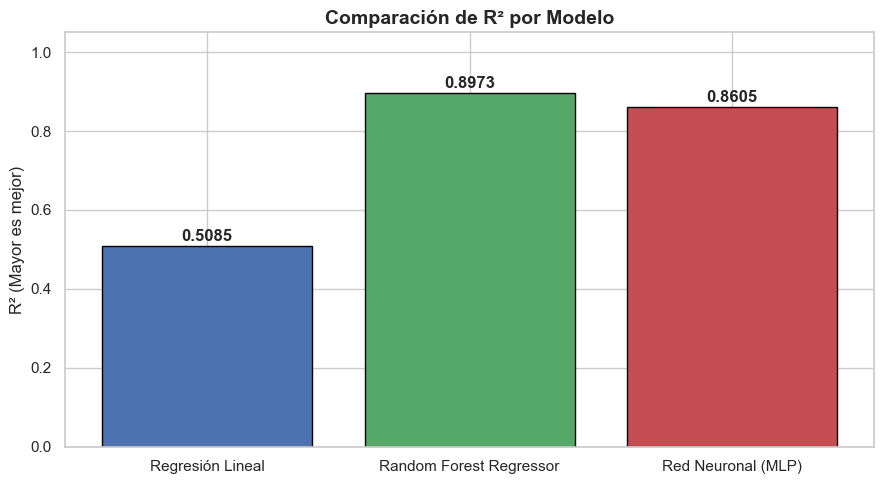

In [25]:
##### Gráfico comparativo de R² ###########
plt.figure(figsize=(9, 5))
colores = ['#4C72B0', '#55A868', '#C44E52']
bars = plt.bar(resultados.index, resultados['R²'], color=colores, edgecolor='black')
for bar, val in zip(bars, resultados['R²']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.title('Comparación de R² por Modelo', fontsize=14, fontweight='bold')
plt.ylabel('R² (Mayor es mejor)')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

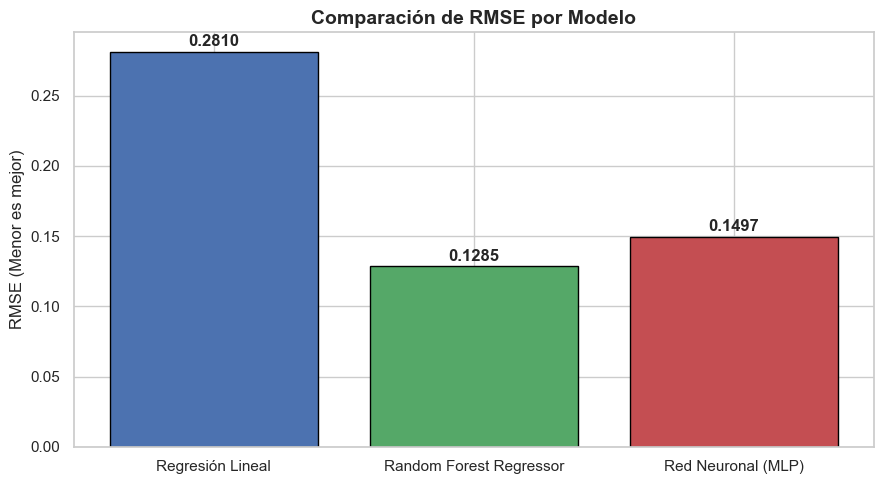

In [26]:
######## Gráfico comparativo de RMSE #########
plt.figure(figsize=(9, 5))
bars = plt.bar(resultados.index, resultados['RMSE'], color=colores, edgecolor='black')
for bar, val in zip(bars, resultados['RMSE']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.title('Comparación de RMSE por Modelo', fontsize=14, fontweight='bold')
plt.ylabel('RMSE (Menor es mejor)')
plt.tight_layout()
plt.show()

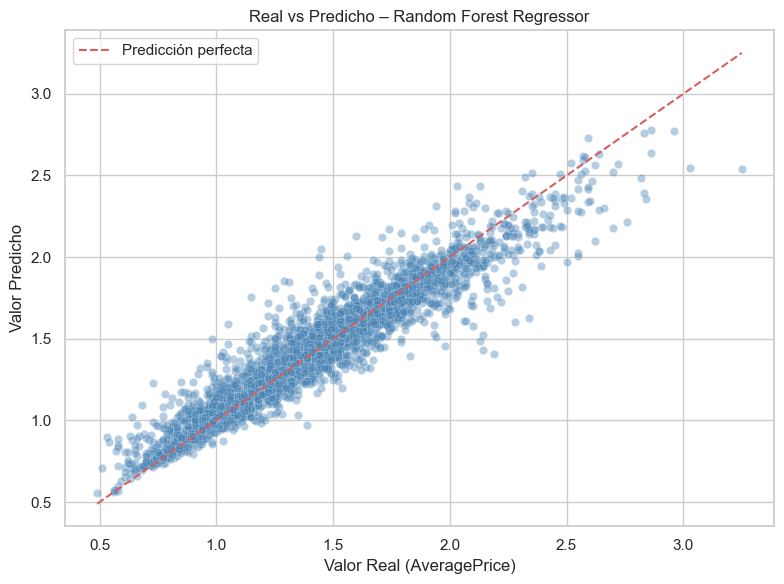

In [27]:
####### Predicho vs Real – Mejor modelo ##########
mejor_pred = y_pred_rf   # Ajusta si otro modelo resulta mejor
mejor_nombre = 'Random Forest Regressor'

plt.figure(figsize=(8, 6))
plt.scatter(y_test, mejor_pred, alpha=0.4, edgecolors='white', linewidth=0.3, color='steelblue')
lims = [min(y_test.min(), mejor_pred.min()), max(y_test.max(), mejor_pred.max())]
plt.plot(lims, lims, 'r--', label='Predicción perfecta')
plt.xlabel('Valor Real (AveragePrice)')
plt.ylabel('Valor Predicho')
plt.title(f'Real vs Predicho – {mejor_nombre}')
plt.legend()
plt.tight_layout()
plt.show()

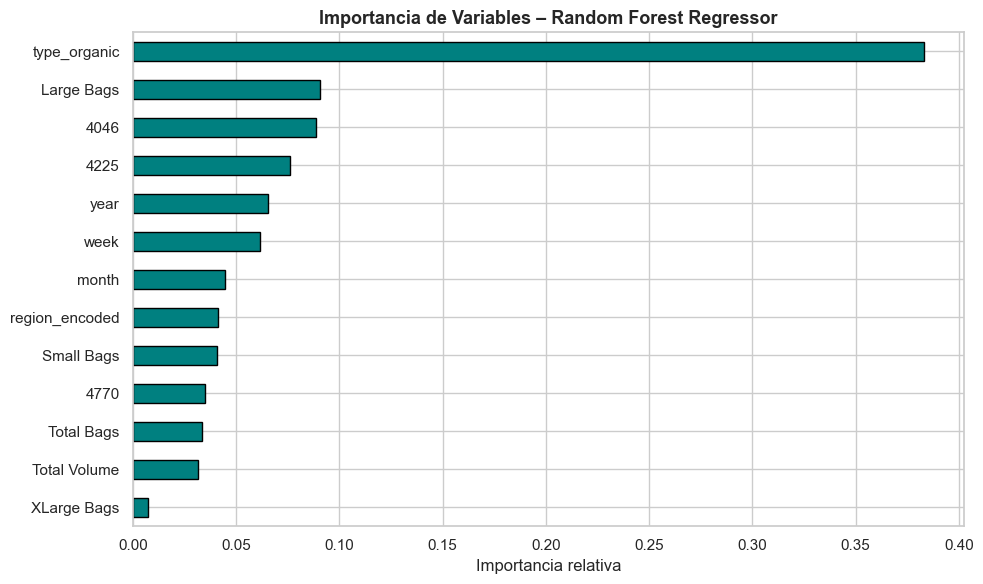

In [28]:
########### Importancia de variables – Random Forest ##########
importancias = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancias.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Importancia de Variables – Random Forest Regressor', fontsize=13, fontweight='bold')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

---
# Fase 4  Conclusiones y Presentación Final

## Análisis del Dataset

El dataset de **Avocado Prices** contiene información semanal de ventas de aguacate en distintas regiones de EE. UU. entre 2015 y 2018. Las variables incluyen el precio promedio, volúmenes de venta por PLU code, tipo de aguacate (`conventional` / `organic`) y la región geográfica.

**Hallazgos principales del EDA:**
- Los aguacates orgánicos alcanzan precios máximos más altos (hasta 3.00 USD) frente a los convencionales (hasta 2.00 USD), aunque los convencionales tienen su pico de densidad en un rango de precio más alto (1.60 USD vs 1.20 USD del orgánico).
- El precio tiene una correlación negativa débil con el volumen vendido (r = -0.19), lo que indica que el volumen explica muy poca variabilidad del precio.
- Las variables de volumen (`Total Volume`, `Total Bags`, `Small Bags`, `Large Bags`) presentan alta multicolinealidad entre sí (r > 0.94), lo que recomienda seleccionar solo una de ellas para modelos lineales.
- Las regiones del noreste (HartfordSpringfield, New York, Philadelphia) tienden a tener los precios más altos, encabezadas por HartfordSpringfield con ~1.80 USD.
- La evolución anual del precio muestra fluctuaciones sin tendencia clara, siendo 2017 el año de precios máximos para ambos tipos.



## Técnicas de Limpieza y Normalización

| Técnica | Justificación |
|--------|---------------|
| Eliminación de columna `Unnamed: 0` | Índice redundante heredado del CSV |
| Conversión de `Date` a datetime | Permite extraer componentes temporales (mes, semana) |
| Extracción de `month` y `week` | Captura estacionalidad y patrones semanales |
| Transformación logarítmica (log1p) | Aplicada a variables de volumen para corregir asimetría extrema sin eliminar datos |
| One-Hot Encoding (`type`) | Variable binaria convertida a dummy (`type_organic`) |
| Label Encoding (`region`) | Reduce dimensionalidad en variable de alta cardinalidad |
| StandardScaler | Necesario para MLP y mejora convergencia en modelos lineales |
| Preservación de todos los datos | No se eliminaron outliers (a diferencia del enfoque inicial con 3×IQR que descartaba ~21%) |



## Modelos Entrenados y Comparación de Desempeño

Se entrenaron tres modelos de regresión dado que la variable objetivo (`AveragePrice`) es continua:

| Modelo | MSE | RMSE | MAE | R² |
|--------|-----|------|-----|-----|
| Regresión Lineal | 0.0790 | 0.2810 | 0.2182 | 0.5085 |
| Random Forest Regressor | 0.0165 | 0.1285 | 0.0897 | 0.8973 |
| Red Neuronal MLP | 0.0224 | 0.1497 | 0.1092 | 0.8605 |

**Conclusiones sobre modelos:**
- Random Forest es el mejor modelo (R² = 0.8973), explicando casi el 90% de la variabilidad del precio.
- La MLP también tiene buen rendimiento, pero es inferior a Random Forest.
- La Regresión Lineal confirma la presencia de relaciones no lineales en los datos.

### Importancia de Variables (Random Forest)

Las variables más influyentes son:
1. `type_organic`
2. `Large Bags`
3. `4046`
4. `4225`
5. `year`


## Posibles Mejoras

- Feature engineering: agregar variables de estacionalidad o rezagos de precio
- Optimización de hiperparámetros con GridSearchCV o RandomSearchCV
- Probar modelos como XGBoost o LightGBM
- Agrupar regiones para reducir cardinalidad
- Aplicar modelos de series de tiempo (ARIMA, Prophet)
- Evaluar transformación del target (`AveragePrice`)